In [4]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
!pip install shap


  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
   ---------------------------------------- 0.0/547.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/547.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/547.0 kB ? eta -:--:--
   ------------------- -------------------- 262.1/547.0 kB ? eta -:--:--
   -------------------------------------- 547.0/547.0 kB 828.2 kB/s eta 0:00:00
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.7 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.7 MB ? eta -:--:--
   ------- -------------------------------- 0.5/2.7 MB 799.2 kB/s eta 0:00:03
   ----------- ---------------------------- 0.8/2.7 MB 819.2 kB/s eta 0:00:03
   ----------- -----


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
# ============================================
# 🌾 Stage 1: Setup & Data Preparation
# ============================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import joblib

# Load and clean
data = pd.read_csv("data/raw/yield_prediction_dataset_3k.csv")  # change filename as needed
data.columns = [c.strip().lower() for c in data.columns]

# Remove missing or invalid rows
data = data.dropna()

X = data.drop(columns=["yield_kg_ha"])
y = data["yield_kg_ha"]

# Identify categorical columns
cat_cols = ["location", "crop", "previous_crop", "irrigation_method"]

encoders = {}

# Encode each categorical column numerically
for col in cat_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    encoders[col] = le  # save encoder for later use

# Now re-split after encoding
X = data.drop(columns=["yield_kg_ha"])
y = data["yield_kg_ha"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("✅ Data loaded and split successfully!")
print("Train shape:", X_train.shape)


✅ Data loaded and split successfully!
Train shape: (2400, 11)


In [22]:
# ============================================
# 🌾 Stage 2: Model Training, Evaluation & Saving
# ============================================
from sklearn.preprocessing import LabelEncoder
# Initialize model
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

# Train model
model.fit(X_train, y_train)
print("✅ Model training completed!")

# Predictions
y_pred = model.predict(X_test)

# Evaluation metrics
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\n📊 Model Performance:")
print(f"R² Score: {r2:.3f}")
print(f"RMSE: {rmse:.2f}")

# ============================================
# Save the trained model
# ============================================

import os

model_dir = r"C:\Users\varsa\Agropulse\app\models"
os.makedirs(model_dir, exist_ok=True)

model_path = os.path.join(model_dir, "yield_model_rf.pkl")
joblib.dump(model, model_path)

print(f"\n✅ Model saved at: {model_path}")


✅ Model training completed!

📊 Model Performance:
R² Score: 0.957
RMSE: 5533.19

✅ Model saved at: C:\Users\varsa\Agropulse\app\models\yield_model_rf.pkl


In [12]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

# --- Train Gradient Boosting ---
gbr_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    random_state=42
)
gbr_model.fit(X_train, y_train)

# Predictions
gbr_pred = gbr_model.predict(X_test)

# Evaluation
gbr_r2 = r2_score(y_test, gbr_pred)
gbr_mae = mean_absolute_error(y_test, gbr_pred)
gbr_rmse = np.sqrt(mean_squared_error(y_test, gbr_pred))

print("\n🔥 Gradient Boosting Performance:")
print(f"R²: {gbr_r2:.3f}")
print(f"MAE: {gbr_mae:.2f}")
print(f"RMSE: {gbr_rmse:.2f}")



🔥 Gradient Boosting Performance:
R²: 0.954
MAE: 3411.66
RMSE: 5743.31


In [14]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_r2 = r2_score(y_test, rf_pred)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

print("\n🌲 Random Forest Performance:")
print(f"R²: {rf_r2:.3f}")
print(f"MAE: {rf_mae:.2f}")
print(f"RMSE: {rf_rmse:.2f}")



🌲 Random Forest Performance:
R²: 0.957
MAE: 3196.99
RMSE: 5533.19


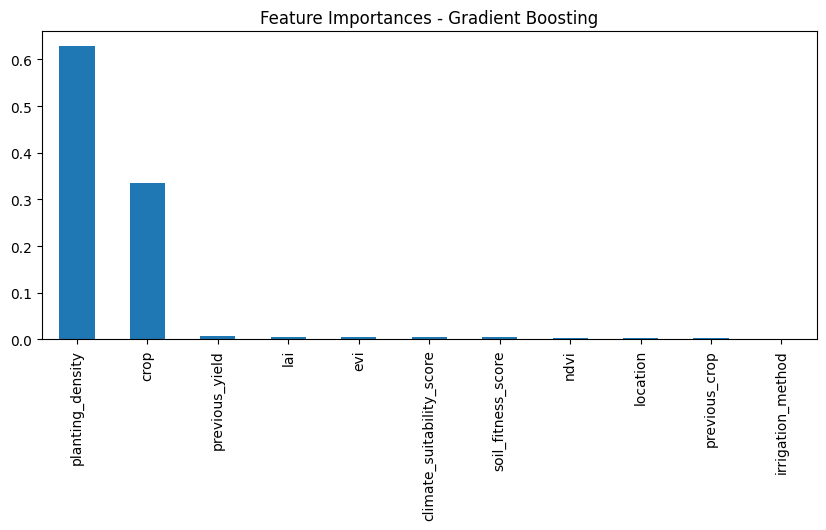

In [19]:
#analyze important features
importances = pd.Series(gbr_model.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).plot(kind='bar', figsize=(10,4))
plt.title("Feature Importances - Gradient Boosting")
plt.show()


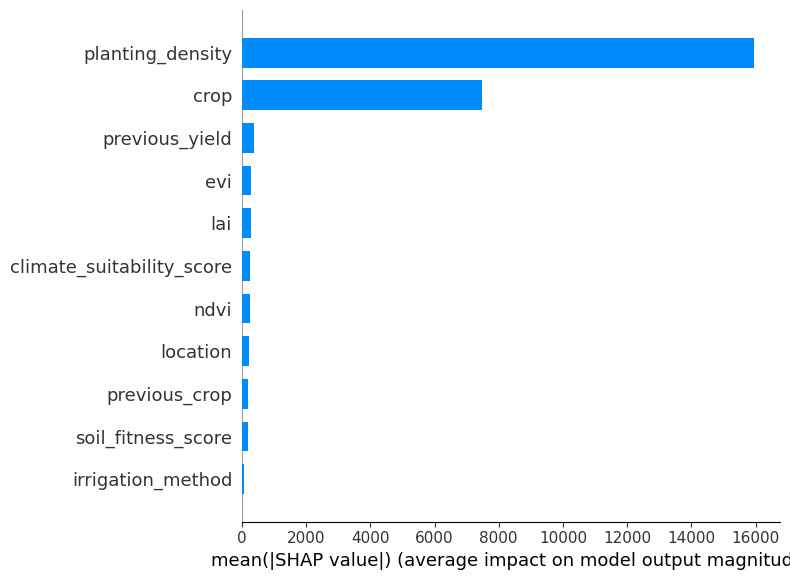

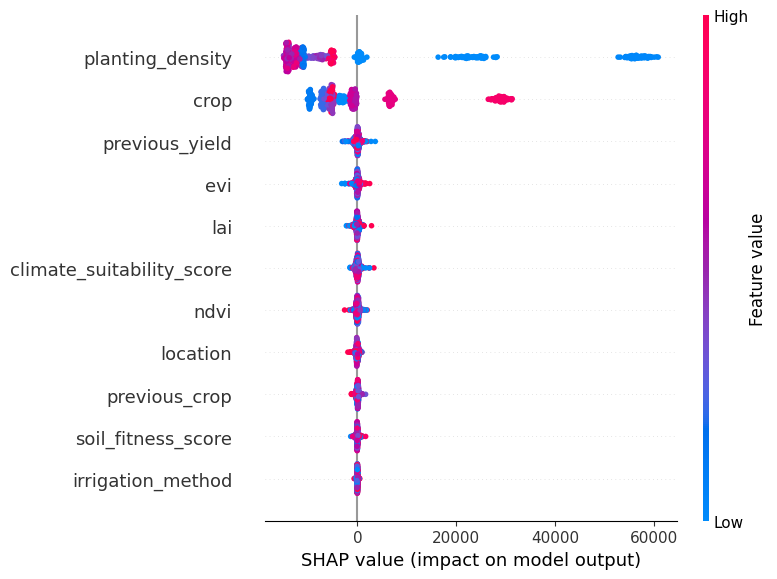

In [21]:


#shap explainability
import shap
explainer = shap.TreeExplainer(gbr_model)
shap_values = explainer.shap_values(X_test)

# Bar summary
shap.summary_plot(shap_values, X_test, plot_type="bar")
# Detailed summary
shap.summary_plot(shap_values, X_test)


In [23]:
#save your best models and encoders
import os
model_dir = r"C:\Users\varsa\Agropulse\app\models"
os.makedirs(model_dir, exist_ok=True)

joblib.dump(gbr_model, os.path.join(model_dir, "yield_model_gbr.pkl"))
joblib.dump(encoders, os.path.join(model_dir, "label_encoders.pkl"))

print("✅ Optimized model and encoders saved successfully!")


✅ Optimized model and encoders saved successfully!


In [1]:
print("varniga")

varniga


In [ ]:
# ============================================
# 🌾 YIELD PREDICTION MODEL TRAINING (AgroPulse)
# ============================================

# --- 1️⃣ Imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import joblib
import shap

# --- 2️⃣ Load Dataset ---
df = pd.read_csv("data/raw/yield_prediction_dataset_3k.csv")
print("✅ Dataset loaded successfully!")
print(df.head())
print("\nShape:", df.shape)

# --- 3️⃣ Basic EDA ---
print("\nCrops distribution:\n", df['crop'].value_counts())
sns.countplot(data=df, x='crop')
plt.title("Crop Distribution")
plt.xticks(rotation=45)
plt.show()

# --- 4️⃣ Encode Categorical Features ---
cat_cols = ['location', 'crop', 'previous_crop', 'irrigation_method']
encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

print("\nEncoded categorical columns:", cat_cols)

# --- 5️⃣ Split Features & Target ---
X = df.drop('yield_kg_ha', axis=1)
y = df['yield_kg_ha']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {len(X_train)}, Testing samples: {len(X_test)}")

# --- 6️⃣ Train Random Forest ---
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_r2 = r2_score(y_test, rf_pred)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

print("\n🌲 Random Forest Performance:")
print(f"R²: {rf_r2:.3f}")
print(f"MAE: {rf_mae:.2f}")
print(f"RMSE: {rf_rmse:.2f}")

# --- 7️⃣ Train Gradient Boosting ---
gbr_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    random_state=42
)
gbr_model.fit(X_train, y_train)

gbr_pred = gbr_model.predict(X_test)

gbr_r2 = r2_score(y_test, gbr_pred)
gbr_mae = mean_absolute_error(y_test, gbr_pred)
gbr_rmse = np.sqrt(mean_squared_error(y_test, gbr_pred))

print("\n🔥 Gradient Boosting Performance:")
print(f"R²: {gbr_r2:.3f}")
print(f"MAE: {gbr_mae:.2f}")
print(f"RMSE: {gbr_rmse:.2f}")

# --- 8️⃣ Compare Models ---
results = pd.DataFrame({
    'Model': ['Random Forest', 'Gradient Boosting'],
    'R²': [rf_r2, gbr_r2],
    'MAE': [rf_mae, gbr_mae],
    'RMSE': [rf_rmse, gbr_rmse]
})
print("\n📊 Model Comparison:")
print(results)

sns.barplot(data=results.melt(id_vars='Model', var_name='Metric', value_name='Score'),
            x='Metric', y='Score', hue='Model')
plt.title("Model Performance Comparison")
plt.show()

# --- 9️⃣ Feature Importance (GBR preferred) ---
importances = pd.Series(gbr_model.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).plot(kind='bar', figsize=(10,4))
plt.title("Feature Importances - Gradient Boosting")
plt.show()

# --- 🔟 SHAP Explainability ---
explainer = shap.TreeExplainer(gbr_model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, plot_type="bar")
shap.summary_plot(shap_values, X_test)


# --- 1️⃣1️⃣ Save Best Model and Encoders ---

import os

# Define your target directory for storing models
model_dir = r"C:\Users\varsa\Agropulse\app\models"

# Create the folder if it doesn’t exist
os.makedirs(model_dir, exist_ok=True)

# Full paths
model_path = os.path.join(model_dir, "yield_model.pkl")
encoder_path = os.path.join(model_dir, "label_encoders.pkl")

# Save model and encoders
joblib.dump(gbr_model, model_path)
joblib.dump(encoders, encoder_path)

print(f"\n✅ Gradient Boosting model saved at: {model_path}")
print(f"✅ Label encoders saved at: {encoder_path}")
